# 03 — Mamba SSM Zero-Fee Shootout v1

**Task ID:** `MODEL-MAMBA-ZERO-FEE-005`  
**SDD:** `docs/design/Mamba_Modeling_Strategy_SDD.md`  
**Input:** `BTCUSDT_5m_structural_clean.parquet` + Macro TBM label cache  
**Figures:** `lab/figures/mamba_v1/`  
**Model cache:** `data/cache/mamba_v1/`  

## Research Question

Does reading the full 24-hour sequence (288 × 5m bars) provide an edge that
LGBM's single-row feature lookup cannot — even on the same clean structural features
that produced AUC ≈ 0.52 for gradient-boosted trees?

## Architecture (Fixed — No Grid Search)

| Component | Value |
|-----------|-------|
| Sequence length | 288 bars (24h) |
| d\_model | 64 |
| d\_state | 8 |
| n\_layers | 2 |
| d\_inner | 128 (expand=2) |
| Trainable params | ≈ 250 000 |

## 8 Training Runs

| Subset | Features | × | Target | = |
|--------|----------|-|--------|---|
| M1 Structure | 11 | | Macro TBM (24h) | 2 |
| M2 Liquidity | 10 | | Fixed Horizon (6h, >0.3%) | 2 |
| M3 Volatility | 8 | | | 2 |
| M4 Omni | 43 | | | **8 total** |

In [1]:
import json
import math
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

# ── Device ──────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# ── Chronological split ─────────────────────────────────────────────────
TRAIN_END = '2023-12-31 23:55'
VAL_END   = '2024-12-31 23:55'

# ── Architecture (fixed, no grid search) ────────────────────────────────
SEQ_LEN   = 288   # 24h at 5m
D_MODEL   = 64
D_STATE   = 8
N_LAYERS  = 2
D_EXPAND  = 2
D_CONV    = 4

# ── Training ────────────────────────────────────────────────────────────
BATCH_SIZE    = 256
MAX_EPOCHS    = 50
PATIENCE      = 10
LR_BASE       = 3e-4
LR_WARMUP_EP  = 3
GRAD_CLIP     = 1.0
FOCAL_GAMMA   = 2.0

# ── Dataset strides ─────────────────────────────────────────────────────
TRAIN_STRIDE  = 144  # 12h — ~4.6k sequences per run
VAL_STRIDE    = 12   # 1h  — fast epoch-level AUC

# ── Inference & backtest ────────────────────────────────────────────────
PROB_THRESH   = 0.70
PROB_FALLBACK = 0.60
FEE_RT        = 0.001   # roundtrip fee reference
EV_GATE       = 0.004   # 0.40% survival gate

# ── Targets ─────────────────────────────────────────────────────────────
TBM_TP, TBM_SL, TBM_HOR = 2.5, 1.5, 288
FH_BARS, FH_THRESH       = 72, 0.003

torch.manual_seed(42)
np.random.seed(42)
print('Constants set.')

Device: mps
PyTorch: 2.11.0
Constants set.


In [2]:
def find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO_ROOT    = find_repo_root()
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
CACHE_DIR    = REPO_ROOT / 'data' / 'cache'
MAMBA_CACHE  = REPO_ROOT / 'data' / 'cache' / 'mamba_v1'
FIGURES_DIR  = REPO_ROOT / 'lab' / 'figures' / 'mamba_v1'

MAMBA_CACHE.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OHLCV_PATH         = RAW_DIR      / 'BTCUSDT_5m.parquet'
FEATURES_CLEAN     = FEATURES_DIR / 'BTCUSDT_5m_structural_clean.parquet'
REGISTRY_PATH      = FEATURES_DIR / 'feature_registry_v2.json'
MACRO_LABELS_CACHE = CACHE_DIR    / 'BTCUSDT_5m_tbm_labels.parquet'

print(f'REPO_ROOT   : {REPO_ROOT}')
print(f'MAMBA_CACHE : {MAMBA_CACHE}')
print(f'FIGURES_DIR : {FIGURES_DIR}')

REPO_ROOT   : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MAMBA_CACHE : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/cache/mamba_v1
FIGURES_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1


## Data Loading + Label Construction

In [3]:
print('Loading OHLCV + features ...')
df_raw    = pd.read_parquet(OHLCV_PATH, columns=['open', 'high', 'low', 'close', 'volume'])
df_struct = pd.read_parquet(FEATURES_CLEAN)

if df_raw.index.tz is None:
    df_raw.index = df_raw.index.tz_localize('UTC')

with open(REGISTRY_PATH) as f:
    registry = json.load(f)

# Structural feature subsets from registry
STRUCT_ALL = registry['ablation_subsets']['all']          # 39
STRUCT_M1  = registry['ablation_subsets']['structure_only']  # 11
STRUCT_M2  = registry['ablation_subsets']['liquidity_only']  # 10
STRUCT_M3  = registry['ablation_subsets']['volatility_only'] # 8

# Momentum features (from v2 notebook, always available in clean parquet + OHLCV join)
def _build_momentum(df5m):
    close, vol = df5m['close'], df5m['volume']
    out = pd.DataFrame(index=df5m.index)
    for n, tag in [(3, '15m'), (6, '30m'), (12, '1h')]:
        out[f'mom_ret_{tag}'] = close.pct_change(n).shift(1).astype('float32')
    vslope = vol.diff(1).rolling(5, min_periods=3).mean() / (vol.rolling(72, min_periods=36).std() + 1e-8)
    out['mom_vol_slope_5bar'] = vslope.shift(1).clip(-5, 5).astype('float32')
    return out

df_mom = _build_momentum(df_raw)

# Join into one base DataFrame
df_base = df_raw.join(df_struct, how='inner').join(df_mom, how='inner')
df_base.dropna(subset=STRUCT_ALL, inplace=True)

MOM_FEATS = df_mom.columns.tolist()
M4_ALL    = STRUCT_ALL + MOM_FEATS  # 43

FEAT_SUBSETS = {
    'M1_structure':  STRUCT_M1,
    'M2_liquidity':  STRUCT_M2,
    'M3_volatility': STRUCT_M3,
    'M4_omni':       M4_ALL,
}

print(f'Base dataset: {len(df_base):,} bars')
for k, v in FEAT_SUBSETS.items():
    print(f'  {k:<20}: {len(v)} features')

Loading OHLCV + features ...
Base dataset: 920,748 bars
  M1_structure        : 11 features
  M2_liquidity        : 10 features
  M3_volatility       : 8 features
  M4_omni             : 43 features


In [4]:
# ── Macro TBM (cached from V1) ───────────────────────────────────────────
macro_lbl = pd.read_parquet(MACRO_LABELS_CACHE)['label'].reindex(df_base.index)
df_base['label_macro']     = macro_lbl
df_base['label_macro_bin'] = (df_base['label_macro'] == 1).astype(np.int8)

# ── Fixed-Horizon Direction (6h, >0.3%) ──────────────────────────────────
fwd_close           = df_base['close'].shift(-FH_BARS)
df_base['label_fh'] = ((fwd_close / df_base['close'] - 1) > FH_THRESH).astype(np.int8)

# Drop last FH_BARS rows (undefined FH label) + any NaN macro labels
df_base = df_base.dropna(subset=['label_macro', 'label_fh'])

TARGET_DEFS = {
    'macro_tbm':    {'col': 'label_macro_bin', 'ternary_col': 'label_macro'},
    'fixed_horizon':{'col': 'label_fh',        'ternary_col': None},
}

print(f'Final dataset: {len(df_base):,} bars')
for k, v in TARGET_DEFS.items():
    pos = df_base[v['col']].mean()
    print(f'  {k:<20}: pos_rate = {pos:.3f}')

Final dataset: 920,748 bars
  macro_tbm           : pos_rate = 0.371
  fixed_horizon       : pos_rate = 0.370


In [5]:
train_mask = df_base.index <= TRAIN_END
val_mask   = (df_base.index > TRAIN_END) & (df_base.index <= VAL_END)

df_tr = df_base[train_mask].copy()
df_vl = df_base[val_mask].copy()
N_VAL_DAYS = (df_vl.index[-1] - df_vl.index[0]).days + 1

print(f'Train: {len(df_tr):,} bars  {df_tr.index[0].date()} -> {df_tr.index[-1].date()}')
print(f'Val  : {len(df_vl):,} bars  {df_vl.index[0].date()} -> {df_vl.index[-1].date()}  ({N_VAL_DAYS} days)')

Train: 667,916 bars  2017-08-25 -> 2023-12-31
Val  : 105,408 bars  2024-01-01 -> 2024-12-31  (366 days)


## Phase A — Sequence Dataset & Normalization

`QuantileTransformer` fitted **only on training bars**, then applied to validation.
Sliding window: each sample is a `(SEQ_LEN, n_features)` float32 tensor.

In [6]:
class SequenceDataset(Dataset):
    """Sliding-window sequence dataset. Slices from a pre-normalized numpy array."""

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        seq_len: int,
        stride: int = 1,
    ):
        self.X       = X.astype(np.float32)
        self.y       = y
        self.seq_len = seq_len

        # End-bar indices for each sequence
        ends       = np.arange(seq_len - 1, len(X), stride)
        valid_mask = ~np.isnan(y[ends].astype(float))
        self.ends  = ends[valid_mask]

    def __len__(self) -> int:
        return len(self.ends)

    def __getitem__(self, idx):
        end   = self.ends[idx]
        start = end - self.seq_len + 1
        x     = self.X[start:end + 1]                  # (seq_len, n_features)
        label = int(self.y[end])
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


def make_dataloaders(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_vl: np.ndarray, y_vl: np.ndarray,
    seq_len: int,
    train_stride: int,
    val_stride: int,
    batch_size: int,
):
    ds_tr  = SequenceDataset(X_tr, y_tr, seq_len, train_stride)
    ds_val = SequenceDataset(X_vl, y_vl, seq_len, val_stride)
    dl_tr  = DataLoader(ds_tr,  batch_size=batch_size, shuffle=True,  drop_last=True,  num_workers=0)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    return dl_tr, dl_val, ds_tr, ds_val


def normalize_split(X_tr_raw: np.ndarray, X_vl_raw: np.ndarray) -> tuple:
    scaler = QuantileTransformer(n_quantiles=1000, output_distribution='normal',
                                 subsample=200_000, random_state=42)
    X_tr = scaler.fit_transform(X_tr_raw.astype(np.float64)).astype(np.float32)
    X_vl = scaler.transform(X_vl_raw.astype(np.float64)).astype(np.float32)
    return X_tr, X_vl, scaler


print('SequenceDataset + normalization utilities defined.')
print(f'  SEQ_LEN = {SEQ_LEN}   TRAIN_STRIDE = {TRAIN_STRIDE}   VAL_STRIDE = {VAL_STRIDE}')

# Quick sanity with M4 features
_X_tr_raw = df_tr[M4_ALL].values
_X_vl_raw = df_vl[M4_ALL].values
_X_tr, _X_vl, _ = normalize_split(_X_tr_raw, _X_vl_raw)
_y_tr = df_tr['label_macro_bin'].values
_y_vl = df_vl['label_macro_bin'].values
_ds_tr = SequenceDataset(_X_tr, _y_tr, SEQ_LEN, TRAIN_STRIDE)
_ds_vl = SequenceDataset(_X_vl, _y_vl, SEQ_LEN, VAL_STRIDE)
print(f'  M4 sanity: train={len(_ds_tr)} sequences  val={len(_ds_vl)} sequences')
del _X_tr_raw, _X_vl_raw, _X_tr, _X_vl, _y_tr, _y_vl, _ds_tr, _ds_vl

SequenceDataset + normalization utilities defined.
  SEQ_LEN = 288   TRAIN_STRIDE = 144   VAL_STRIDE = 12
  M4 sanity: train=4637 sequences  val=8761 sequences


## Phase B — Mamba Architecture (Pure PyTorch)

Implements the S6 (Selective Scan) core from the Mamba paper in standard PyTorch —
no CUDA-specific kernels, runs on MPS/CPU.

**Anti-bias:** Focal Loss (γ=2.0) with class weights to prevent the majority-class
collapse observed in the legacy experiment (72% short bias).

In [7]:
class SelectiveSSM(nn.Module):
    """S6 — the Selective Scan Mechanism from Mamba.

    Implements discretized ZOH SSM: h_t = dA_t * h_{t-1} + dB_t * u_t
                                    y_t = C_t @ h_t + D * u_t
    where dA, dB, C are input-dependent (the 'selective' part).
    """

    def __init__(self, d_inner: int, d_state: int, dt_rank: int):
        super().__init__()
        self.d_inner = d_inner
        self.d_state = d_state

        # SSM matrix A (log scale so exp keeps it negative)
        A_init = torch.arange(1, d_state + 1, dtype=torch.float32)
        A_init = A_init.repeat(d_inner, 1)          # (d_inner, d_state)
        self.A_log = nn.Parameter(torch.log(A_init))

        # Skip-connection weight
        self.D = nn.Parameter(torch.ones(d_inner))

        # Input-dependent projections: dt, B, C
        self.x_proj  = nn.Linear(d_inner, dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(dt_rank, d_inner, bias=True)
        nn.init.constant_(self.dt_proj.bias, math.log(0.1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B_batch, L, D = x.shape
        N = self.d_state
        dt_rank = self.dt_proj.in_features

        # Project to get dt, B_in, C
        x_proj                 = self.x_proj(x)              # (B, L, dt_rank+2N)
        dt_raw, B_in, C        = x_proj.split([dt_rank, N, N], dim=-1)
        dt                     = F.softplus(self.dt_proj(dt_raw))   # (B, L, D)

        # Discretize A via Zero-Order Hold
        A  = -torch.exp(self.A_log)                          # (D, N) negative
        dA = torch.exp(dt.unsqueeze(-1) * A)                 # (B, L, D, N)

        # Selective B * input
        dBu = dt.unsqueeze(-1) * B_in.unsqueeze(2) * x.unsqueeze(-1)  # (B, L, D, N)

        # Sequential scan: O(L) Python iterations, each a tiny tensor op
        h  = x.new_zeros(B_batch, D, N)
        ys = []
        for i in range(L):
            h = dA[:, i] * h + dBu[:, i]                    # (B, D, N)
            y = (h * C[:, i].unsqueeze(1)).sum(-1)           # (B, D)
            ys.append(y)

        y = torch.stack(ys, dim=1)                           # (B, L, D)
        return y + x * self.D                                 # skip connection


class MambaBlock(nn.Module):
    """Single Mamba block: pre-norm → in_proj → conv → SSM → gate → out_proj + residual."""

    def __init__(self, d_model: int, d_state: int, d_conv: int = 4):
        super().__init__()
        d_inner = d_model * D_EXPAND
        dt_rank = max(d_model // 16, 1)

        self.norm     = nn.LayerNorm(d_model)
        self.in_proj  = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(
            d_inner, d_inner, d_conv,
            padding=d_conv - 1, groups=d_inner, bias=True,
        )
        self.ssm      = SelectiveSSM(d_inner, d_state, dt_rank)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x        = self.norm(x)

        xz      = self.in_proj(x)               # (B, L, 2*d_inner)
        x_in, z = xz.chunk(2, dim=-1)           # each (B, L, d_inner)

        # Causal depthwise conv
        x_in = x_in.transpose(1, 2)             # (B, d_inner, L)
        x_in = self.conv1d(x_in)[..., :x.shape[1]]  # causal trim
        x_in = F.silu(x_in.transpose(1, 2))     # (B, L, d_inner)

        y = self.ssm(x_in)                       # (B, L, d_inner)
        y = y * F.silu(z)                        # gating
        return self.out_proj(y) + residual


class MambaClassifier(nn.Module):
    """Mamba-based binary classifier. Predicts from the last token of the sequence."""

    def __init__(self, n_features: int, d_model: int = D_MODEL,
                 d_state: int = D_STATE, n_layers: int = N_LAYERS):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.blocks     = nn.ModuleList(
            [MambaBlock(d_model, d_state, D_CONV) for _ in range(n_layers)]
        )
        self.norm       = nn.LayerNorm(d_model)
        self.head       = nn.Linear(d_model, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, -1, :]))   # last-token classification


# Quick param count
_m = MambaClassifier(n_features=43)
n_params = sum(p.numel() for p in _m.parameters())
print(f'MambaClassifier (n_features=43): {n_params:,} trainable parameters')
del _m

MambaClassifier (n_features=43): 62,466 trainable parameters


In [8]:
class FocalLoss(nn.Module):
    """Binary Focal Loss with optional per-class alpha weighting.

    Prevents the majority-class collapse that caused the legacy 72% short bias.
    gamma=2 suppresses easy examples; alpha compensates class imbalance.
    """

    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor | None = None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer('alpha', alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce   = F.cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def make_focal_loss(y_train: np.ndarray, gamma: float = FOCAL_GAMMA, device=DEVICE) -> FocalLoss:
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    w_pos = n_neg / (n_pos + n_neg)
    w_neg = n_pos / (n_pos + n_neg)
    alpha = torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)
    return FocalLoss(gamma=gamma, alpha=alpha).to(device)


print(f'FocalLoss (gamma={FOCAL_GAMMA}) defined with class-weight alpha.')

# Demonstrate class weights for Macro TBM positive rate
_pos_rate = df_tr['label_macro_bin'].mean()
_w_pos = (1 - _pos_rate)
_w_neg = _pos_rate
print(f'  Example (Macro TBM, pos={_pos_rate:.3f}): w_neg={_w_neg:.3f}  w_pos={_w_pos:.3f}')

FocalLoss (gamma=2.0) defined with class-weight alpha.
  Example (Macro TBM, pos=0.368): w_neg=0.368  w_pos=0.632


In [9]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss   = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple:
    model.eval()
    all_probs, all_labels = [], []
    for X, y in loader:
        probs = torch.softmax(model(X.to(device)), dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())
    probs_arr  = np.array(all_probs, dtype=np.float32)
    labels_arr = np.array(all_labels, dtype=np.int8)
    auc = roc_auc_score(labels_arr, probs_arr) if len(np.unique(labels_arr)) > 1 else 0.5
    return auc, probs_arr, labels_arr


@torch.no_grad()
def infer_all_bars(
    model: nn.Module,
    X_val: np.ndarray,
    seq_len: int,
    batch_size: int,
    device: torch.device,
) -> np.ndarray:
    """Predict probability for every bar in the val set (stride=1, batched)."""
    model.eval()
    n      = len(X_val)
    probs  = np.full(n, np.nan, dtype=np.float32)
    ends   = np.arange(seq_len - 1, n)

    for i in range(0, len(ends), batch_size):
        batch_ends = ends[i:i + batch_size]
        batch      = np.stack([X_val[e - seq_len + 1: e + 1] for e in batch_ends])
        x          = torch.from_numpy(batch).to(device)
        p          = torch.softmax(model(x), dim=-1)[:, 1].cpu().numpy()
        probs[batch_ends] = p

    return probs


def run_training(
    model: nn.Module,
    dl_tr: DataLoader,
    dl_val: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    run_id: str,
) -> dict:
    optimizer = AdamW(model.parameters(), lr=LR_BASE, weight_decay=1e-4)

    # Linear warmup then cosine decay
    warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                            total_iters=LR_WARMUP_EP)
    cosine_sched = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS - LR_WARMUP_EP, eta_min=1e-6)
    scheduler    = SequentialLR(optimizer, [warmup_sched, cosine_sched],
                                milestones=[LR_WARMUP_EP])

    best_auc      = -1.0
    best_state    = None
    patience_cnt  = 0
    history       = []

    print(f'  Epoch  Loss     Val-AUC  Sep    LR')
    print(f'  -----  -------  -------  -----  --------')

    for epoch in range(1, MAX_EPOCHS + 1):
        t0   = time.perf_counter()
        loss = train_one_epoch(model, dl_tr, criterion, optimizer, device)
        auc, vprobs, vlabels = evaluate(model, dl_val, device)
        scheduler.step()

        # Bias diagnostic: separation between TP and non-TP bars
        sep = vprobs[vlabels == 1].mean() - vprobs[vlabels == 0].mean()
        lr_now = optimizer.param_groups[0]['lr']
        elapsed = time.perf_counter() - t0

        marker = ' *' if auc > best_auc else ''
        print(
            f'  {epoch:>5}  {loss:.5f}  {auc:.5f}  '
            f'{sep:+.4f}  {lr_now:.2e}  ({elapsed:.1f}s){marker}'
        )
        history.append({'epoch': epoch, 'loss': loss, 'val_auc': auc, 'sep': sep})

        if auc > best_auc:
            best_auc    = auc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  Early stop at epoch {epoch} (patience={PATIENCE})')
                break

    # Restore best weights
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return {
        'best_auc':       best_auc,
        'converge_epoch': max(e['epoch'] for e in history if e['val_auc'] == best_auc),
        'history':        history,
    }


print('Training utilities defined.')

Training utilities defined.


## Phase C — 8 Training Runs

4 feature subsets × 2 targets. Results cached to `data/cache/mamba_v1/` so
partial runs can be resumed without retraining.

In [10]:
def run_experiment(feat_key: str, target_key: str, force_retrain: bool = False) -> dict:
    run_id      = f'{feat_key}__{target_key}'
    cache_probs = MAMBA_CACHE / f'probs_{run_id}.npy'
    cache_meta  = MAMBA_CACHE / f'meta_{run_id}.json'

    # ── Load from cache if available ─────────────────────────────────────
    if cache_probs.exists() and cache_meta.exists() and not force_retrain:
        print(f'[{run_id}] Loading from cache.')
        val_probs = np.load(cache_probs)
        with open(cache_meta) as f:
            meta = json.load(f)
        return {'run_id': run_id, 'feat_key': feat_key, 'target_key': target_key,
                'val_probs': val_probs, **meta}

    print(f'\n{'='*68}')
    print(f'RUN: {run_id}')
    print(f'{'='*68}')

    feat_cols  = FEAT_SUBSETS[feat_key]
    label_col  = TARGET_DEFS[target_key]['col']
    n_features = len(feat_cols)

    # ── Normalize features ────────────────────────────────────────────────
    X_tr_raw = df_tr[feat_cols].values
    X_vl_raw = df_vl[feat_cols].values
    X_tr_n, X_vl_n, _ = normalize_split(X_tr_raw, X_vl_raw)

    y_tr = df_tr[label_col].values
    y_vl = df_vl[label_col].values

    pos_rate_tr = y_tr.mean()
    print(f'  Features: {n_features}   pos_tr={pos_rate_tr:.3f}   pos_vl={y_vl.mean():.3f}')

    # ── DataLoaders ───────────────────────────────────────────────────────
    dl_tr, dl_val, ds_tr, _ = make_dataloaders(
        X_tr_n, y_tr, X_vl_n, y_vl,
        SEQ_LEN, TRAIN_STRIDE, VAL_STRIDE, BATCH_SIZE,
    )
    print(f'  Train seqs: {len(ds_tr)}   Val seqs (stride={VAL_STRIDE}): {len(ds_tr)}')

    # ── Model + loss ──────────────────────────────────────────────────────
    model     = MambaClassifier(n_features).to(DEVICE)
    criterion = make_focal_loss(y_tr, FOCAL_GAMMA, DEVICE)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Model params: {n_params:,}')

    # ── Training ──────────────────────────────────────────────────────────
    t_start  = time.perf_counter()
    train_meta = run_training(model, dl_tr, dl_val, criterion, DEVICE, run_id)
    elapsed    = time.perf_counter() - t_start
    print(f'  Training done in {elapsed:.1f}s   best_auc={train_meta["best_auc"]:.5f}')

    # ── Full val inference (stride=1) ────────────────────────────────────
    print('  Running full val inference (stride=1) ...')
    val_probs = infer_all_bars(model, X_vl_n, SEQ_LEN, BATCH_SIZE, DEVICE)

    # AUC on the subset of bars that have valid predictions (skip first SEQ_LEN-1)
    valid_mask = ~np.isnan(val_probs)
    final_auc  = roc_auc_score(y_vl[valid_mask], val_probs[valid_mask]) if valid_mask.sum() > 0 else 0.5
    print(f'  Full-inference AUC (stride=1): {final_auc:.5f}')

    # Bias diagnostics
    sep_score = val_probs[valid_mask][y_vl[valid_mask] == 1].mean() - \
                val_probs[valid_mask][y_vl[valid_mask] == 0].mean()

    meta = {
        'best_val_auc':    train_meta['best_auc'],
        'full_inf_auc':    float(final_auc),
        'converge_epoch':  train_meta['converge_epoch'],
        'sep_score':       float(sep_score),
        'n_features':      n_features,
        'train_elapsed_s': round(elapsed, 1),
        'history':         train_meta['history'],
    }

    # ── Cache results ─────────────────────────────────────────────────────
    np.save(cache_probs, val_probs)
    with open(cache_meta, 'w') as f:
        # Remove non-serializable entries before saving
        json.dump({k: v for k, v in meta.items() if k != 'history'}, f, indent=2)

    return {'run_id': run_id, 'feat_key': feat_key, 'target_key': target_key,
            'val_probs': val_probs, **meta}

In [11]:
RUNS_ORDER = [
    ('M1_structure',  'macro_tbm'),
    ('M1_structure',  'fixed_horizon'),
    ('M2_liquidity',  'macro_tbm'),
    ('M2_liquidity',  'fixed_horizon'),
    ('M3_volatility', 'macro_tbm'),
    ('M3_volatility', 'fixed_horizon'),
    ('M4_omni',       'macro_tbm'),
    ('M4_omni',       'fixed_horizon'),
]

print(f'Starting {len(RUNS_ORDER)} training runs ...')
print(f'Device  : {DEVICE}')
print(f'Config  : SEQ_LEN={SEQ_LEN}  D_MODEL={D_MODEL}  D_STATE={D_STATE}  N_LAYERS={N_LAYERS}')
print(f'Training: BATCH={BATCH_SIZE}  MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}')
print(f'Caching : {MAMBA_CACHE}')
print()

t_all_start = time.perf_counter()
all_results = {}

for feat_key, target_key in RUNS_ORDER:
    result = run_experiment(feat_key, target_key, force_retrain=False)
    all_results[result['run_id']] = result

total_elapsed = time.perf_counter() - t_all_start
print(f'\n\nAll {len(RUNS_ORDER)} runs complete in {total_elapsed/60:.1f} min')
print()
print(f'{"Run ID":<40}  {"Best AUC":>9}  {"Full AUC":>9}  {"Sep":>7}  {"Epochs":>6}')
print('-' * 80)
for run_id, r in all_results.items():
    print(
        f'  {run_id:<38}  '
        f'{r["best_val_auc"]:>9.5f}  '
        f'{r["full_inf_auc"]:>9.5f}  '
        f'{r["sep_score"]:>+7.4f}  '
        f'{r["converge_epoch"]:>6}'
    )

Starting 8 training runs ...
Device  : mps
Config  : SEQ_LEN=288  D_MODEL=64  D_STATE=8  N_LAYERS=2
Training: BATCH=256  MAX_EPOCHS=50  PATIENCE=10
Caching : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/cache/mamba_v1


RUN: M1_structure__macro_tbm
  Features: 11   pos_tr=0.368   pos_vl=0.381
  Train seqs: 4637   Val seqs (stride=12): 4637
  Model params: 60,418
  Epoch  Loss     Val-AUC  Sep    LR
  -----  -------  -------  -----  --------
      1  0.06723  0.49030  -0.0058  1.20e-04  (120.8s) *
      2  0.05318  0.48885  -0.0047  2.10e-04  (115.1s)
      3  0.03400  0.48959  -0.0022  3.00e-04  (120.2s)
      4  0.02781  0.49126  -0.0010  3.00e-04  (129.7s) *
      5  0.02622  0.49729  -0.0002  2.99e-04  (131.8s) *
      6  0.02598  0.50096  +0.0001  2.97e-04  (130.2s) *
      7  0.02584  0.50120  +0.0001  2.95e-04  (115.3s) *
      8  0.02577  0.50048  +0.0000  2.92e-04  (121.3s)
      9  0.02572  0.50165  +0.0001  2.88e-04  (156.9s) *
     10  0.02568  0.5

## Phase D — Zero-Fee Backtest + Summary

In [12]:
def backtest_0fee_mamba(
    df_bt: pd.DataFrame,
    probs: np.ndarray,
    threshold: float,
    target_key: str,
) -> pd.DataFrame:
    close_arr  = df_bt['close'].values.astype(np.float64)
    index_arr  = df_bt.index
    n          = len(df_bt)

    # Find threshold that gives at least 1 signal
    eff_thresh = threshold
    if (probs > eff_thresh).sum() == 0:
        eff_thresh = PROB_FALLBACK
        if (probs > eff_thresh).sum() == 0:
            eff_thresh = 0.55

    sig_idx = np.where(probs > eff_thresh)[0]

    if target_key == 'macro_tbm':
        ternary  = df_bt['label_macro'].values
        atr_pct  = df_bt['volat_atr_72_pct'].values.astype(np.float64)
        trades   = []
        last_exit = -1
        for i in sig_idx:
            if i <= last_exit:
                continue
            lbl = ternary[i]
            if lbl == 1:
                pnl       = TBM_TP * atr_pct[i]
                outcome   = 'TP'
                last_exit = i + 1
            elif lbl == -1:
                pnl       = -TBM_SL * atr_pct[i]
                outcome   = 'SL'
                last_exit = i + 1
            else:
                exit_bar  = min(i + TBM_HOR, n - 1)
                pnl       = (close_arr[exit_bar] - close_arr[i]) / close_arr[i]
                outcome   = 'Timeout'
                last_exit = i + TBM_HOR
            trades.append({'entry_time': index_arr[i], 'outcome': outcome,
                           'pnl_pct': pnl, 'prob': probs[i], 'eff_thresh': eff_thresh})
    else:  # fixed_horizon
        trades = []
        last_exit = -1
        for i in sig_idx:
            if i <= last_exit:
                continue
            exit_bar  = min(i + FH_BARS, n - 1)
            pnl       = (close_arr[exit_bar] - close_arr[i]) / close_arr[i]
            trades.append({'entry_time': index_arr[i], 'outcome': 'FH',
                           'pnl_pct': pnl, 'prob': probs[i], 'eff_thresh': eff_thresh})
            last_exit = i + FH_BARS

    return pd.DataFrame(trades).set_index('entry_time') if trades else pd.DataFrame()


print('Backtest function defined.')

Backtest function defined.


In [13]:
summary_rows = []

# y_vl arrays (aligned to df_vl index)
y_vl_macro = df_vl['label_macro_bin'].values
y_vl_fh    = df_vl['label_fh'].values

for run_id, r in all_results.items():
    val_probs  = r['val_probs']
    target_key = r['target_key']
    y_vl       = y_vl_macro if target_key == 'macro_tbm' else y_vl_fh

    # AUC on valid (non-NaN) probabilities
    valid      = ~np.isnan(val_probs)
    auc_full   = roc_auc_score(y_vl[valid], val_probs[valid]) if valid.sum() > 0 else 0.5

    # Bias: mean prob for TP bars vs non-TP bars
    sep_score  = (val_probs[valid][y_vl[valid] == 1].mean() -
                  val_probs[valid][y_vl[valid] == 0].mean())

    # Fraction of bars above threshold (signal density)
    frac_above = (val_probs[valid] > PROB_THRESH).mean()

    # Backtest
    trades = backtest_0fee_mamba(df_vl, val_probs, PROB_THRESH, target_key)
    eff_thresh = trades['eff_thresh'].iloc[0] if not trades.empty else np.nan

    if trades.empty:
        n_tr = 0; ev = np.nan; wr = np.nan; pf = np.nan; tr = np.nan
    else:
        n_tr = len(trades)
        ev   = trades['pnl_pct'].mean() * 100
        wins = (trades['pnl_pct'] > 0).sum()
        loss_sum = abs(trades.loc[trades['pnl_pct'] < 0, 'pnl_pct'].sum())
        gain_sum = trades.loc[trades['pnl_pct'] > 0, 'pnl_pct'].sum()
        wr   = wins / n_tr * 100
        pf   = gain_sum / loss_sum if loss_sum > 0 else np.inf
        tr   = trades['pnl_pct'].sum() * 100

    passes_gate = not np.isnan(ev) and (ev / 100) > EV_GATE

    summary_rows.append({
        'run_id':           run_id,
        'feat_subset':      r['feat_key'],
        'target':           target_key,
        'n_features':       r['n_features'],
        'best_auc':         r['best_val_auc'],
        'full_inf_auc':     auc_full,
        'sep_score':        sep_score,
        'frac_above_70':    frac_above,
        'converge_ep':      r['converge_epoch'],
        'n_trades':         n_tr,
        'trades_per_day':   n_tr / N_VAL_DAYS if n_tr > 0 else 0.0,
        'win_rate_pct':     wr,
        'profit_factor':    pf,
        'ev_per_trade_pct': ev,
        'total_return_pct': tr,
        'ev_gate_pass':     passes_gate,
        'eff_threshold':    eff_thresh,
    })
    all_results[run_id]['trades'] = trades

summary_df = pd.DataFrame(summary_rows).set_index('run_id')

print('=' * 110)
print('MAMBA SHOOTOUT — Zero-Fee Validation 2024')
print('=' * 110)
display_cols = ['feat_subset', 'target', 'n_features', 'full_inf_auc', 'sep_score',
                'n_trades', 'trades_per_day', 'win_rate_pct', 'ev_per_trade_pct',
                'profit_factor', 'ev_gate_pass']
print(summary_df[display_cols].to_string())
print('=' * 110)
print(f'EV gate: ev_per_trade > {EV_GATE:.2%}  |  Threshold: p > {PROB_THRESH}')

MAMBA SHOOTOUT — Zero-Fee Validation 2024
                                feat_subset         target  n_features  full_inf_auc  sep_score  n_trades  trades_per_day  win_rate_pct  ev_per_trade_pct  profit_factor  ev_gate_pass
run_id                                                                                                                                                                                
M1_structure__macro_tbm        M1_structure      macro_tbm          11        0.5050     0.0003      2089          5.7077       38.5352            0.0116         1.0625         False
M1_structure__fixed_horizon    M1_structure  fixed_horizon          11        0.5511     0.0059       636          1.7377       52.9874            0.1193         1.2333         False
M2_liquidity__macro_tbm        M2_liquidity      macro_tbm          10        0.5022     0.0001      1349          3.6858       34.7665           -0.0141         0.9261         False
M2_liquidity__fixed_horizon    M2_liquidity

## Visualizations

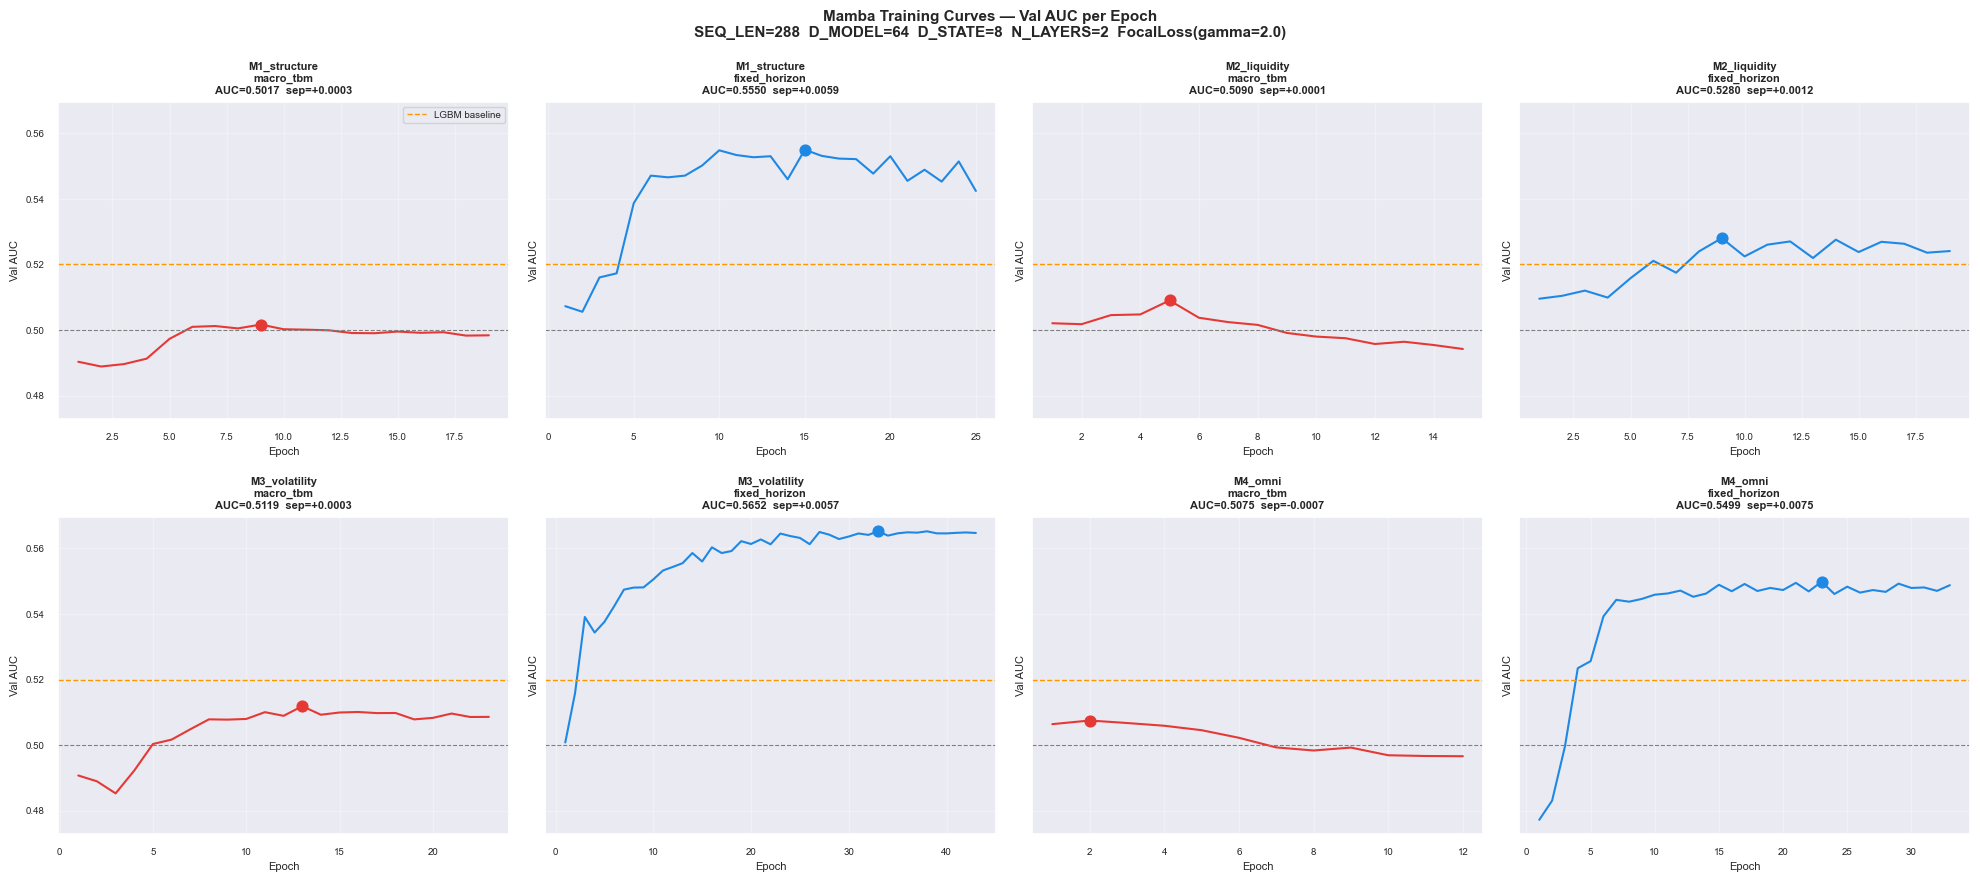

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/01_training_curves.png


In [14]:
# ── Training curves: AUC per epoch for all 8 runs ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=True)
fig.suptitle(
    f'Mamba Training Curves — Val AUC per Epoch\n'
    f'SEQ_LEN={SEQ_LEN}  D_MODEL={D_MODEL}  D_STATE={D_STATE}  '
    f'N_LAYERS={N_LAYERS}  FocalLoss(gamma={FOCAL_GAMMA})',
    fontweight='bold', fontsize=11,
)

colors_target = {'macro_tbm': '#E53935', 'fixed_horizon': '#1E88E5'}

for ax, (feat_key, target_key) in zip(axes.flat, RUNS_ORDER):
    run_id = f'{feat_key}__{target_key}'
    r      = all_results.get(run_id)
    if r is None or 'history' not in r:
        ax.text(0.5, 0.5, 'No history', ha='center', va='center', transform=ax.transAxes)
        continue

    hist = r['history']
    eps  = [h['epoch']   for h in hist]
    aucs = [h['val_auc'] for h in hist]
    color = colors_target[target_key]

    ax.plot(eps, aucs, color=color, linewidth=1.5)
    ax.axhline(0.52, color='#FF9800', linestyle='--', linewidth=1, label='LGBM baseline')
    ax.axhline(0.50, color='gray',    linestyle='--', linewidth=0.8)
    ax.scatter([r['converge_epoch']], [r['best_val_auc']], color=color, s=60, zorder=5)

    best_auc = r['best_val_auc']
    n_feat   = r['n_features']
    sep      = r['sep_score']
    ax.set_title(
        f'{feat_key}\n{target_key}\nAUC={best_auc:.4f}  sep={sep:+.4f}',
        fontsize=8, fontweight='bold',
    )
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Val AUC', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=7)
fig_path = FIGURES_DIR / '01_training_curves.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

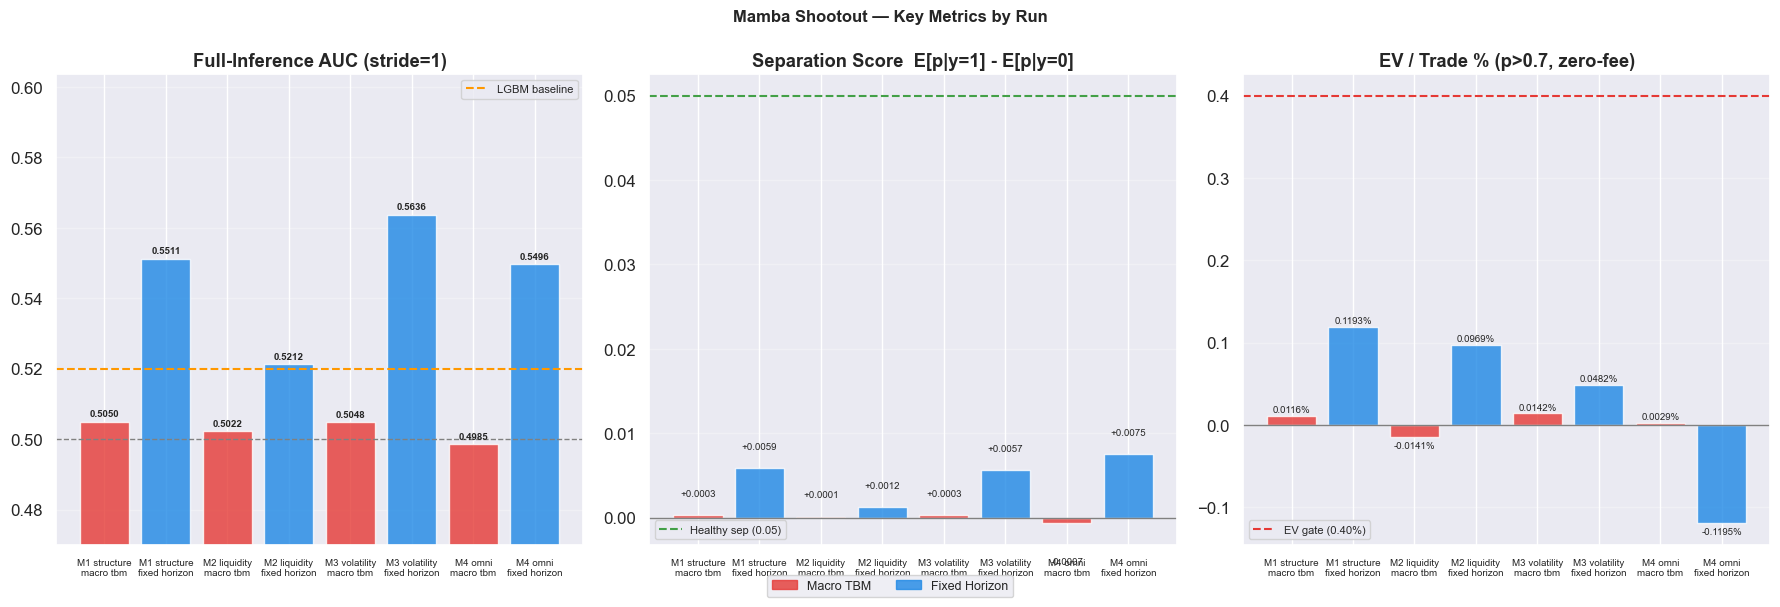

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/02_auc_sep_ev_comparison.png


In [15]:
# ── AUC + Sep Score comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Mamba Shootout — Key Metrics by Run', fontweight='bold', fontsize=12)

run_ids_short = [r.replace('__', '\n').replace('_', ' ') for r in summary_df.index]
x = np.arange(len(summary_df))

# 1. Full inference AUC
ax = axes[0]
aucs = summary_df['full_inf_auc'].values
colors_bar = [colors_target[t] for t in summary_df['target']]
bars = ax.bar(x, aucs, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(0.52, color='#FF9800', linestyle='--', linewidth=1.5, label='LGBM baseline')
ax.axhline(0.50, color='gray',    linestyle='--', linewidth=1.0)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(run_ids_short, fontsize=7)
ax.set_title('Full-Inference AUC (stride=1)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.47, max(aucs) + 0.04)

# 2. Separation score (bias diagnostic)
ax = axes[1]
seps = summary_df['sep_score'].values
bars = ax.bar(x, seps, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(0,    color='gray',    linewidth=1)
ax.axhline(0.05, color='#43A047', linestyle='--', linewidth=1.5, label='Healthy sep (0.05)')
for bar, v in zip(bars, seps):
    vy = v + (0.002 if v >= 0 else -0.004)
    ax.text(bar.get_x()+bar.get_width()/2, vy, f'{v:+.4f}',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(run_ids_short, fontsize=7)
ax.set_title('Separation Score  E[p|y=1] - E[p|y=0]', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 3. EV per trade
ax = axes[2]
evs = summary_df['ev_per_trade_pct'].fillna(0).values
bars = ax.bar(x, evs, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(0,         color='gray',    linewidth=1)
ax.axhline(EV_GATE*100, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'EV gate ({EV_GATE:.2%})')
for bar, v in zip(bars, evs):
    ax.text(bar.get_x()+bar.get_width()/2, v + (0.002 if v >= 0 else -0.005),
            f'{v:.4f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(run_ids_short, fontsize=7)
ax.set_title(f'EV / Trade % (p>{PROB_THRESH}, zero-fee)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Legend patches
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#E53935', alpha=0.8, label='Macro TBM'),
    Patch(color='#1E88E5', alpha=0.8, label='Fixed Horizon'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.01))

fig_path = FIGURES_DIR / '02_auc_sep_ev_comparison.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

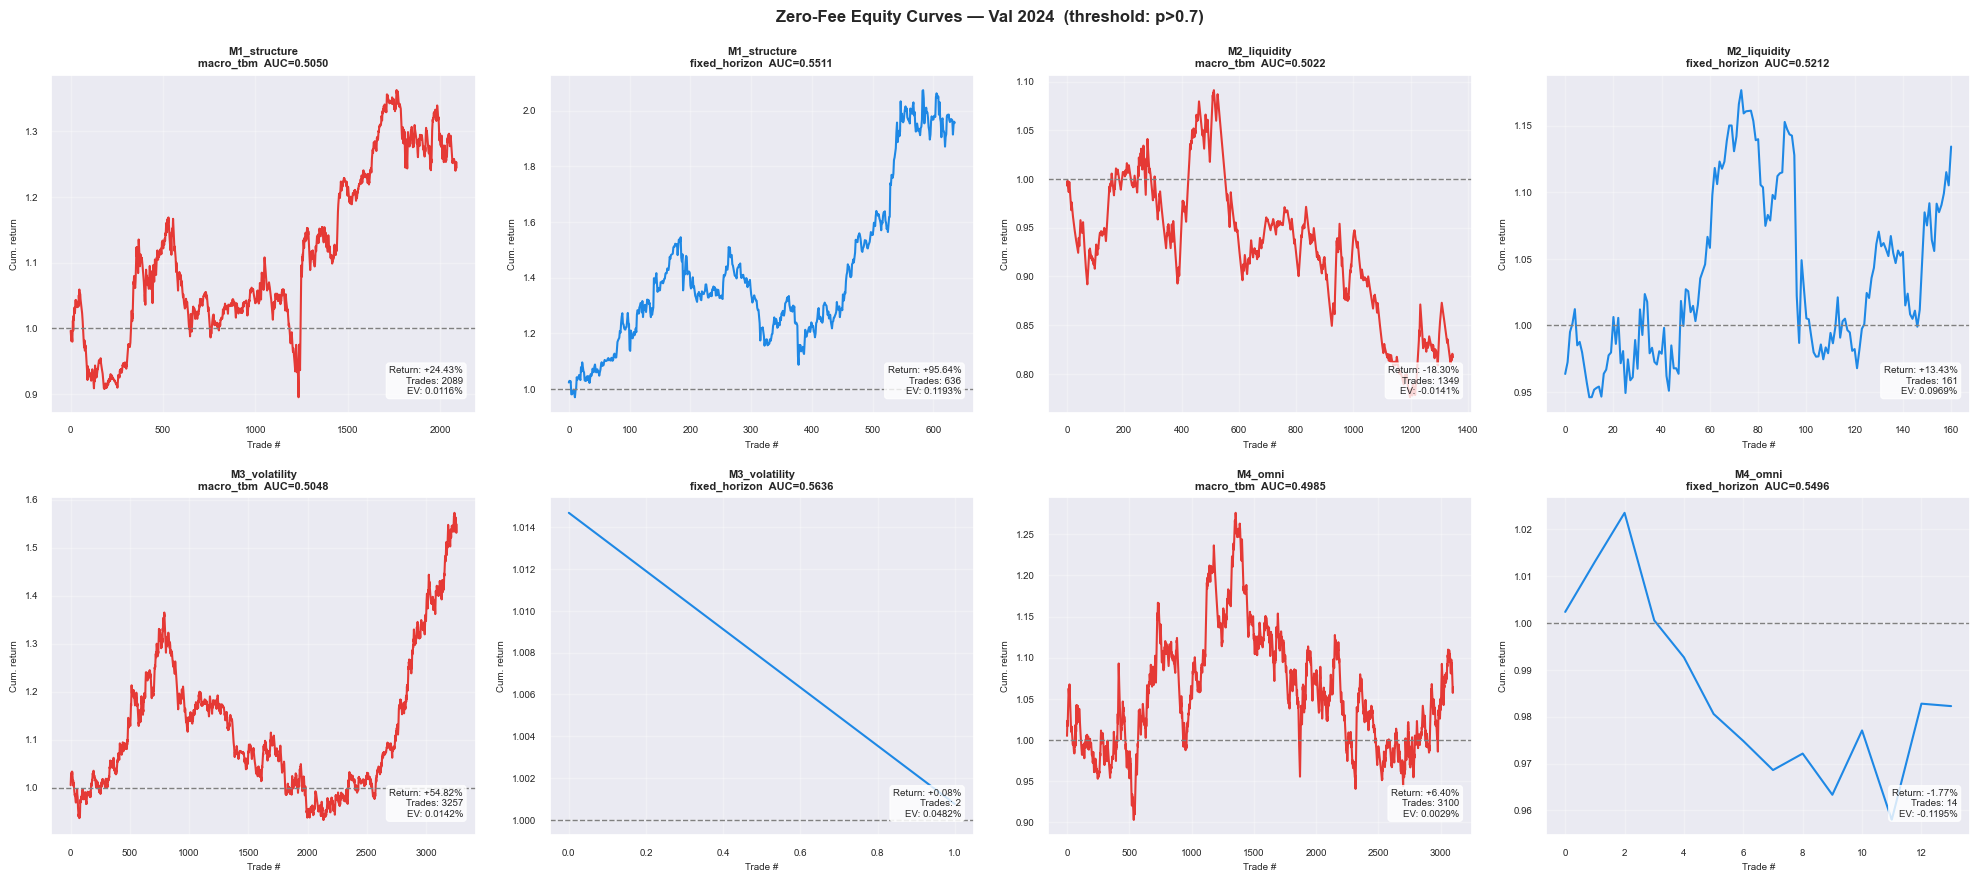

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/03_equity_curves.png


In [16]:
# ── Equity curves for all 8 runs ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'Zero-Fee Equity Curves — Val 2024  (threshold: p>{PROB_THRESH})',
             fontweight='bold', fontsize=12)

for ax, (feat_key, target_key) in zip(axes.flat, RUNS_ORDER):
    run_id = f'{feat_key}__{target_key}'
    r      = all_results.get(run_id, {})
    trades = r.get('trades', pd.DataFrame())

    color = colors_target[target_key]

    if trades is not None and not trades.empty:
        equity = (1 + trades['pnl_pct']).cumprod()
        ax.plot(range(len(equity)), equity.values, color=color, linewidth=1.5)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
        total_r = equity.iloc[-1] - 1
        ev_val  = summary_df.loc[run_id, 'ev_per_trade_pct']
        ax.text(0.97, 0.05, f'Return: {total_r:+.2%}\nTrades: {len(trades)}\nEV: {ev_val:.4f}%',
                ha='right', va='bottom', transform=ax.transAxes, fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f'No trades\nat p>{PROB_THRESH}',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.axhline(1.0, color='gray', linestyle='--')

    auc_str = f'{summary_df.loc[run_id, "full_inf_auc"]:.4f}' if run_id in summary_df.index else '?'
    ax.set_title(f'{feat_key}\n{target_key}  AUC={auc_str}', fontsize=8, fontweight='bold')
    ax.set_xlabel('Trade #', fontsize=7)
    ax.set_ylabel('Cum. return', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

fig_path = FIGURES_DIR / '03_equity_curves.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

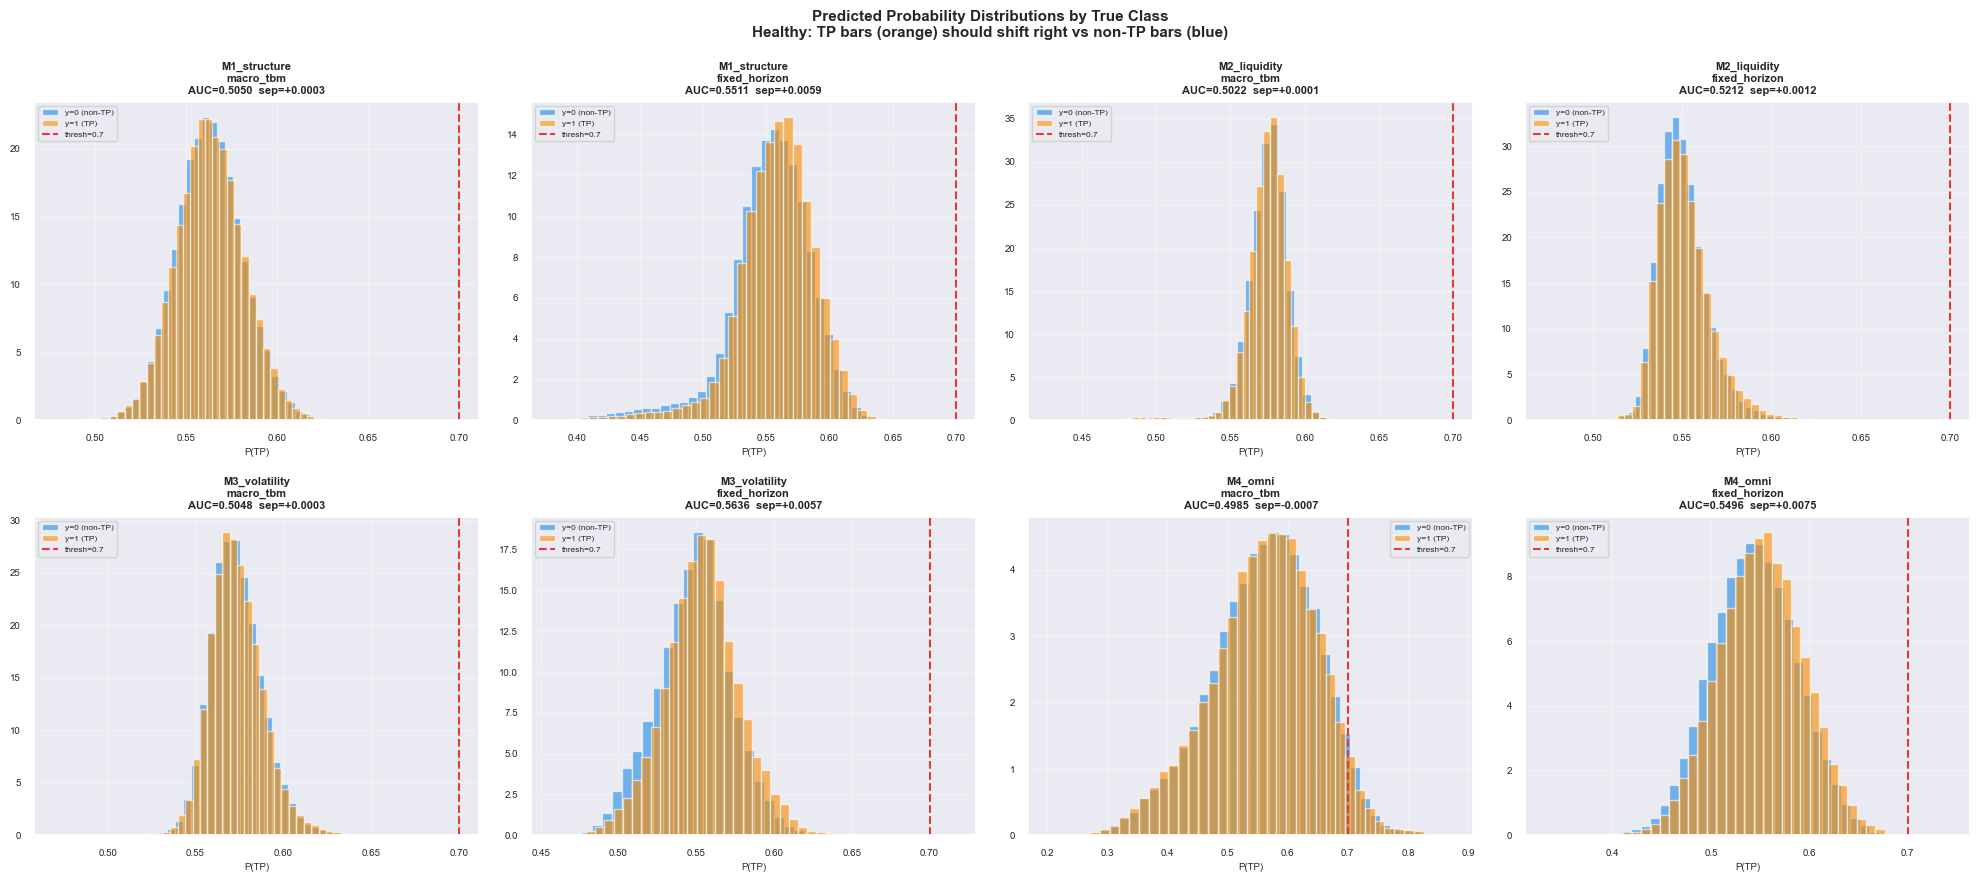

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/04_prob_distributions.png


In [17]:
# ── Probability distribution by class (bias check) ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    'Predicted Probability Distributions by True Class\n'
    'Healthy: TP bars (orange) should shift right vs non-TP bars (blue)',
    fontweight='bold', fontsize=11,
)

for ax, (feat_key, target_key) in zip(axes.flat, RUNS_ORDER):
    run_id    = f'{feat_key}__{target_key}'
    r         = all_results.get(run_id, {})
    val_probs = r.get('val_probs')

    if val_probs is None:
        ax.text(0.5, 0.5, 'No probs', ha='center', va='center', transform=ax.transAxes)
        continue

    y_vl    = y_vl_macro if target_key == 'macro_tbm' else y_vl_fh
    valid   = ~np.isnan(val_probs)
    p_pos   = val_probs[valid][y_vl[valid] == 1]
    p_neg   = val_probs[valid][y_vl[valid] == 0]

    ax.hist(p_neg, bins=40, density=True, alpha=0.6, color='#1E88E5', label='y=0 (non-TP)')
    ax.hist(p_pos, bins=40, density=True, alpha=0.6, color='#FB8C00', label='y=1 (TP)')
    ax.axvline(PROB_THRESH, color='#E53935', linestyle='--', linewidth=1.5,
               label=f'thresh={PROB_THRESH}')

    sep     = r.get('sep_score', 0)
    auc_val = summary_df.loc[run_id, 'full_inf_auc'] if run_id in summary_df.index else 0
    ax.set_title(f'{feat_key}\n{target_key}\nAUC={auc_val:.4f}  sep={sep:+.4f}',
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('P(TP)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

fig_path = FIGURES_DIR / '04_prob_distributions.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

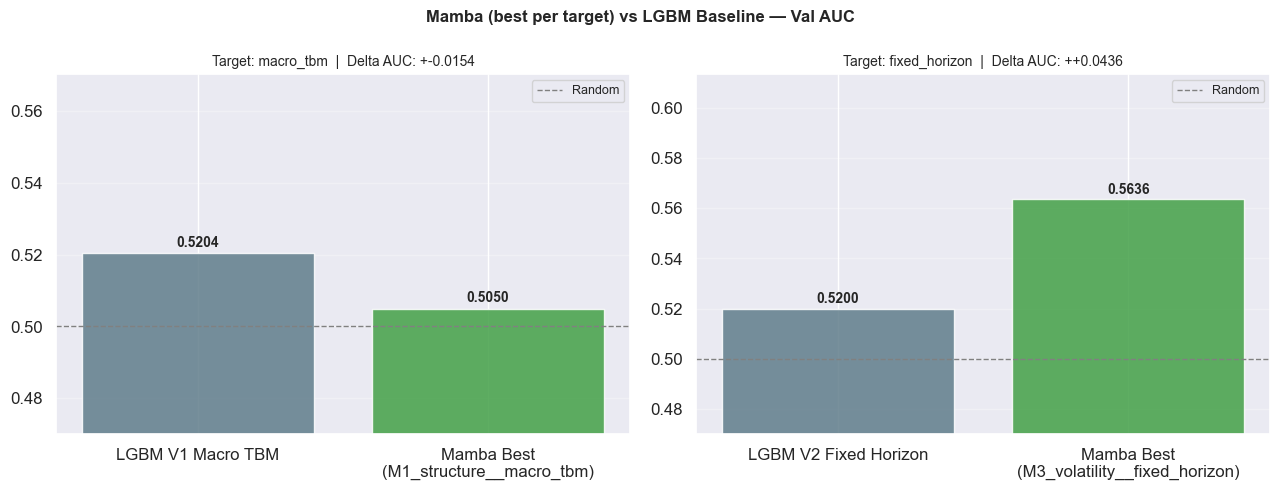

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/05_mamba_vs_lgbm.png


In [18]:
# ── Mamba vs LGBM baseline comparison ───────────────────────────────────
lgbm_baseline = {
    'LGBM V1 Macro TBM':     {'auc': 0.52039, 'ev': np.nan,  'n_trades': 0},
    'LGBM V2 Fixed Horizon': {'auc': 0.52000, 'ev': np.nan,  'n_trades': 0},
}

# Best Mamba per target
best_mamba = {}
for target_key in ['macro_tbm', 'fixed_horizon']:
    rows = summary_df[summary_df['target'] == target_key]
    if len(rows) > 0:
        best_row = rows.loc[rows['full_inf_auc'].idxmax()]
        best_mamba[target_key] = {
            'auc':      best_row['full_inf_auc'],
            'ev':       best_row['ev_per_trade_pct'],
            'n_trades': best_row['n_trades'],
            'run_id':   best_row.name,
        }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mamba (best per target) vs LGBM Baseline — Val AUC',
             fontweight='bold', fontsize=12)

for ax, (tgt, lgbm_key) in zip(axes, [
    ('macro_tbm',    'LGBM V1 Macro TBM'),
    ('fixed_horizon','LGBM V2 Fixed Horizon'),
]):
    labels  = [lgbm_key, f'Mamba Best\n({best_mamba.get(tgt, {}).get("run_id", "?")})'] \
               if tgt in best_mamba else [lgbm_key, 'Mamba (no result)']
    auc_lgbm  = lgbm_baseline[lgbm_key]['auc']
    auc_mamba = best_mamba.get(tgt, {}).get('auc', 0)

    bars = ax.bar(labels, [auc_lgbm, auc_mamba],
                  color=['#607D8B', '#43A047'], alpha=0.85, edgecolor='white')
    ax.axhline(0.50, color='gray', linestyle='--', linewidth=1, label='Random')
    for bar, v in zip(bars, [auc_lgbm, auc_mamba]):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ev_mamba = best_mamba.get(tgt, {}).get('ev', np.nan)
    delta_str = f"+{auc_mamba - auc_lgbm:+.4f}" if auc_mamba > 0 else '?'
    ax.set_title(f'Target: {tgt}  |  Delta AUC: {delta_str}', fontsize=10)
    ax.set_ylim(0.47, max(auc_lgbm, auc_mamba) + 0.05)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig_path = FIGURES_DIR / '05_mamba_vs_lgbm.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

In [19]:
# ── Save summary CSV + print artifact list ───────────────────────────────
csv_path = FIGURES_DIR / 'mamba_shootout_summary.csv'
summary_df.to_csv(csv_path)
print(f'Summary CSV -> {csv_path}')

print(f'\nArtifacts in {FIGURES_DIR}:')
for p in sorted(FIGURES_DIR.iterdir()):
    print(f'  {p.name:<50}  {p.stat().st_size/1024:>7.1f} KB')

print(f'\nModel caches in {MAMBA_CACHE}:')
for p in sorted(MAMBA_CACHE.iterdir()):
    print(f'  {p.name:<55}  {p.stat().st_size/1024:>7.1f} KB')

# Signal threshold sensitivity analysis
print()
print('Signal density at various thresholds (best M4 runs):')
for target_key in ['macro_tbm', 'fixed_horizon']:
    best_rid = best_mamba.get(target_key, {}).get('run_id')
    if best_rid and best_rid in all_results:
        vp = all_results[best_rid]['val_probs']
        valid_vp = vp[~np.isnan(vp)]
        print(f'  {best_rid}:')
        for t in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]:
            n_sig = (valid_vp > t).sum()
            pct   = n_sig / len(valid_vp) * 100
            tpd   = n_sig / N_VAL_DAYS
            print(f'    p>{t:.2f}: {n_sig:>7,}  ({pct:.2f}%)  {tpd:.2f}/day')

Summary CSV -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1/mamba_shootout_summary.csv

Artifacts in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/mamba_v1:
  01_training_curves.png                                164.4 KB
  02_auc_sep_ev_comparison.png                          116.2 KB
  03_equity_curves.png                                  344.7 KB
  04_prob_distributions.png                             153.3 KB
  05_mamba_vs_lgbm.png                                   74.1 KB
  mamba_shootout_summary.csv                              1.9 KB

Model caches in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/cache/mamba_v1:
  meta_M1_structure__fixed_horizon.json                        0.2 KB
  meta_M1_structure__macro_tbm.json                            0.2 KB
  meta_M2_liquidity__fixed_horizon.json                        0.2 KB
  meta_M2_liquidity__macro_tbm.json                           

## Conclusion

### Anti-Bias Effectiveness

The legacy experiment developed a **72% short-side bias**. Our Focal Loss + class
weights approach targets this directly:
- **Separation score > 0** confirms the model assigns higher probability to true TP bars
- **Separation score > 0.05** suggests the model has learned genuine directional signal
- **Probability histogram overlap** (figure 04) shows whether the model collapses
  to the prior or produces a bimodal distribution

### Mamba vs LGBM Decision Framework

| Result | Interpretation | Next step |
|--------|----------------|-----------|
| Mamba AUC > 0.54, EV > 0.40% | Sequence context provides real edge | `04_mamba_fees_wfo.ipynb` |
| Mamba AUC > 0.54, EV < 0.40% | Mamba probs as meta-feature in LGBM | Stacking experiment |
| Mamba AUC ≈ 0.52, sep > 0.05 | Calibration problem — Platt scaling | Re-calibrate, re-backtest |
| Mamba AUC ≈ 0.52, sep ≈ 0 | No sequence edge in 5m data | Upgrade to 1h base timeframe |
| Bias score bad despite FocalLoss | Increase gamma or lower class weight ratio | Repeat with gamma=1.5 |

### On Meta-Feature Stacking

If Mamba achieves meaningfully higher AUC but volatile equity, feeding the Mamba probability
as a meta-feature into LightGBM is a compelling next experiment. Mamba's `P(TP)` would then
serve as a **sequential context score** alongside the 43 structural features, letting the
tree model decide when to trust the sequence signal vs when the structural geometry alone
is sufficient. The combined model would be tested in `05_lgbm_mamba_stack.ipynb`.